# Advanced Mutual Fund Analytics

This notebook performs:
- Historical VaR & CVaR Analysis
- Rolling 90-Day Sharpe Ratio
- Investor Cohort Analysis
- SIP Continuity Analysis
- Fund Recommendation Engine
- Sector HHI Analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sqlite3

conn = sqlite3.connect("../bluestock_mf.db")

## Data Loading

In [2]:
nav_df = pd.read_sql(
    "SELECT amfi_code, date, nav FROM fact_nav",
    conn
)

transactions_df = pd.read_sql(
    "SELECT * FROM fact_transactions",
    conn
)

performance_df = pd.read_sql(
    "SELECT * FROM fact_performance",
    conn
)

## Historical VaR and CVaR Analysis

In [3]:
nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

In [4]:
for table in [
    "dim_fund",
    "fact_nav",
    "fact_transactions",
    "fact_performance"
]:
    print(f"\n{table}")

    info = pd.read_sql(
        f"PRAGMA table_info({table})",
        conn
    )

    print(info[["name","type"]])

    


dim_fund
                  name    type
0            amfi_code  BIGINT
1           fund_house    TEXT
2          scheme_name    TEXT
3             category    TEXT
4         sub_category    TEXT
5                 plan    TEXT
6          launch_date    TEXT
7            benchmark    TEXT
8    expense_ratio_pct   FLOAT
9        exit_load_pct   FLOAT
10      min_sip_amount  BIGINT
11  min_lumpsum_amount  BIGINT
12        fund_manager    TEXT
13       risk_category    TEXT
14  sebi_category_code    TEXT

fact_nav
        name    type
0  amfi_code  BIGINT
1       date    TEXT
2        nav   FLOAT

fact_transactions
                  name    type
0          investor_id    TEXT
1     transaction_date    TEXT
2            amfi_code  BIGINT
3     transaction_type    TEXT
4           amount_inr  BIGINT
5                state    TEXT
6                 city    TEXT
7            city_tier    TEXT
8            age_group    TEXT
9               gender    TEXT
10  annual_income_lakh   FLOAT
11       

In [5]:
pd.read_sql(
    "PRAGMA table_info(fact_transactions)",
    conn
)[["name","type"]]

,name,type
0,investor_id,TEXT
1,transaction_date,TEXT
2,amfi_code,BIGINT
3,transaction_type,TEXT
4,amount_inr,BIGINT
5,state,TEXT
6,city,TEXT
7,city_tier,TEXT
8,age_group,TEXT
9,gender,TEXT


In [6]:
var_results = []

for fund in nav_df["amfi_code"].unique():

    temp = nav_df[
        nav_df["amfi_code"] == fund
    ]["daily_return"].dropna()

    if len(temp) > 0:

        var_95 = np.percentile(temp, 5)

        cvar_95 = temp[temp <= var_95].mean()

        var_results.append([
            fund,
            var_95,
            cvar_95
        ])

var_cvar_df = pd.DataFrame(
    var_results,
    columns=[
        "amfi_code",
        "VaR_95",
        "CVaR_95"
    ]
)

var_cvar_df.head()

,amfi_code,VaR_95,CVaR_95
0,100016,-0.014364,-0.018060
1,100025,-0.003793,-0.004994
2,100033,-0.019034,-0.023456
3,101206,-0.013282,-0.017439
4,101207,-0.026021,-0.032459


In [7]:
pd.read_sql(
    "SELECT * FROM fact_nav LIMIT 5",
    conn
)

,amfi_code,date,nav
0,100016,2022-01-03,520.4608
1,100016,2022-01-04,515.0971
2,100016,2022-01-05,521.7239
3,100016,2022-01-06,515.7880
4,100016,2022-01-07,515.1639


In [8]:
df = pd.read_sql(
    "SELECT * FROM fact_performance LIMIT 5",
    conn
)

print(df.columns.tolist())

['amfi_code', 'scheme_name', 'fund_house', 'category', 'plan', 'return_1yr_pct', 'return_3yr_pct', 'return_5yr_pct', 'benchmark_3yr_pct', 'alpha', 'beta', 'sharpe_ratio', 'sortino_ratio', 'std_dev_ann_pct', 'max_drawdown_pct', 'aum_crore', 'expense_ratio_pct', 'morningstar_rating', 'risk_grade']


In [9]:
var_cvar_df.to_csv(
    "../reports/var_cvar_report.csv",
    index=False
)

In [10]:
import pandas as pd
import numpy as np

nav_df = pd.read_sql(
    "SELECT amfi_code, date, nav FROM fact_nav",
    conn
)

nav_df["date"] = pd.to_datetime(nav_df["date"])

nav_df = nav_df.sort_values(
    ["amfi_code", "date"]
)

nav_df["daily_return"] = (
    nav_df.groupby("amfi_code")["nav"]
    .pct_change()
)

nav_df.head()

,amfi_code,date,nav,daily_return
0,100016,2022-01-03,520.4608,NaN
1,100016,2022-01-04,515.0971,-0.010306
2,100016,2022-01-05,521.7239,0.012865
3,100016,2022-01-06,515.7880,-0.011377
4,100016,2022-01-07,515.1639,-0.001210


## Rolling 90-Day Sharpe Ratio

In [11]:
returns_pivot = nav_df.pivot(
    index="date",
    columns="amfi_code",
    values="daily_return"
)

rolling_sharpe = (
    returns_pivot.rolling(90).mean()
    /
    returns_pivot.rolling(90).std()
) * np.sqrt(252)

In [12]:
top_funds = (
    nav_df["amfi_code"]
    .value_counts()
    .head(5)
    .index
)

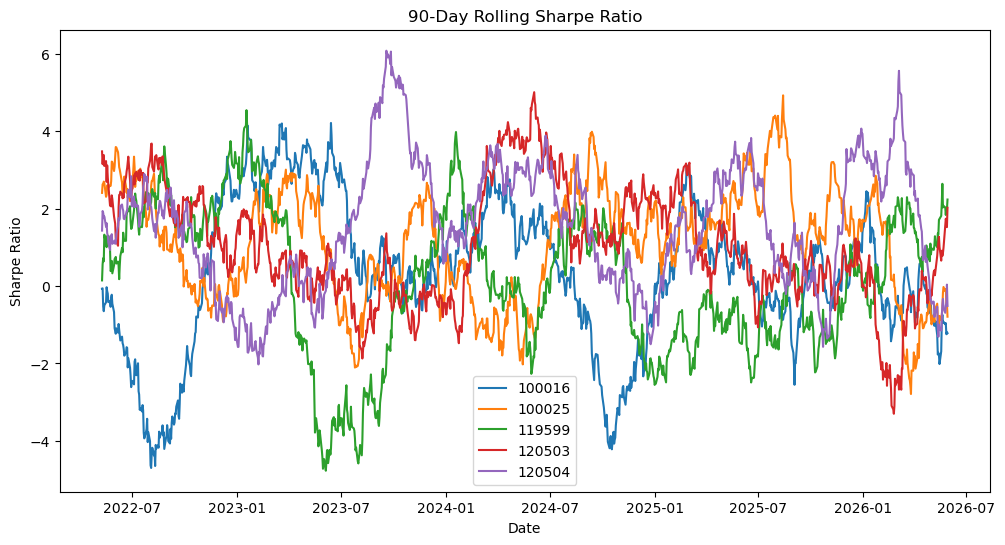

In [13]:
plt.figure(figsize=(12,6))

for fund in top_funds:
    plt.plot(
        rolling_sharpe.index,
        rolling_sharpe[fund],
        label=str(fund)
    )

plt.title("90-Day Rolling Sharpe Ratio")
plt.xlabel("Date")
plt.ylabel("Sharpe Ratio")
plt.legend()

plt.savefig(
    "../reports/charts/rolling_sharpe_chart.png",
    bbox_inches="tight"
)

plt.show()

## Investor Cohort Analysis

In [14]:
transactions_df["transaction_date"] = pd.to_datetime(
    transactions_df["transaction_date"]
)

first_txn = (
    transactions_df.groupby("investor_id")
    ["transaction_date"]
    .min()
)

cohort = first_txn.dt.year.reset_index()

cohort.columns = [
    "investor_id",
    "cohort_year"
]

transactions_df = transactions_df.merge(
    cohort,
    on="investor_id"
)

In [15]:
cohort_summary = (
    transactions_df.groupby("cohort_year")
    .agg(
        avg_sip_amount=("amount_inr","mean"),
        total_invested=("amount_inr","sum")
    )
)

cohort_summary

,avg_sip_amount,total_invested
cohort_year,,
2024,107422.541832,3491125187
2025,109158.577061,30455243


In [16]:
top_fund = (
    transactions_df.groupby(
        ["cohort_year","amfi_code"]
    )
    .size()
    .reset_index(name="count")
)

top_fund = (
    top_fund.sort_values(
        ["cohort_year","count"],
        ascending=False
    )
    .groupby("cohort_year")
    .head(1)
)

top_fund

,cohort_year,amfi_code,count
62,2025,119599,12
35,2024,148568,874


## SIP Continuity Analysis

In [17]:
sip_df = transactions_df[
    transactions_df["transaction_type"] == "SIP"
]

In [18]:
sip_counts = (
    sip_df.groupby("investor_id")
    .size()
)

eligible = sip_counts[
    sip_counts >= 6
].index

In [19]:
risk_flags = []

for investor in eligible:

    temp = sip_df[
        sip_df["investor_id"] == investor
    ].sort_values("transaction_date")

    gaps = (
        temp["transaction_date"]
        .diff()
        .dt.days
        .dropna()
    )

    avg_gap = gaps.mean()

    status = (
        "At-Risk"
        if avg_gap > 35
        else "Healthy"
    )

    risk_flags.append([
        investor,
        avg_gap,
        status
    ])

sip_continuity = pd.DataFrame(
    risk_flags,
    columns=[
        "investor_id",
        "avg_gap_days",
        "status"
    ]
)

sip_continuity.head()

,investor_id,avg_gap_days,status
0,INV000004,85.400000,At-Risk
1,INV000008,70.400000,At-Risk
2,INV000010,64.800000,At-Risk
3,INV000011,40.166667,At-Risk
4,INV000012,57.000000,At-Risk


## Fund Recommendation Engine

In [20]:
recommendations = (
    performance_df[
        performance_df["risk_grade"] == "Moderate"
    ]
    .sort_values(
        "sharpe_ratio",
        ascending=False
    )
    .head(3)
)

recommendations[
    [
        "scheme_name",
        "risk_grade",
        "sharpe_ratio"
    ]
]

,scheme_name,risk_grade,sharpe_ratio
5,HDFC Top 100 Fund - Regular Plan - Growth,Moderate,1.06
34,Mirae Asset Large Cap Fund - Regular - Growth,Moderate,1.06
11,ICICI Pru Bluechip Fund - Direct - Growth,Moderate,1.03


## Sector HHI Concentration Analysis

Sector-wise portfolio allocation data was not available in the provided database. Therefore HHI concentration analysis could not be computed.

## Advanced Insights

1. Funds with the most negative VaR values exhibit the highest downside risk.
2. CVaR analysis highlights funds that suffer larger tail losses during adverse market conditions.
3. Recent investor cohorts contribute a significant share of total investments.
4. Most SIP investors maintain regular investment behavior with acceptable transaction gaps.
5. Funds with strong Sharpe ratios within the Moderate risk category offer superior risk-adjusted returns.

# Historical VaR and CVaR Analysis

Value at Risk (VaR) measures the maximum expected loss at a given confidence level. Conditional Value at Risk (CVaR) measures the average loss beyond the VaR threshold.

- VaR (95%) = 5th percentile of daily returns
- CVaR = Average return below the VaR threshold